<a href="https://colab.research.google.com/github/Cesiaf/-ISPC-Procesamiento-Habla-2026/blob/main/ACTIVIDAD_GUIADA_SECUENCIAL_TPH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#ACTIVIDAD GUIADA SECUENCIAL: DEL SONIDO AL ANÁLISIS EXPLORATORIO

##Procesamiento Digital de Señales de Audio - Eje I Completo

Instrucciones para el estudiante:

Este notebook está diseñado para ejecutarse de arriba hacia abajo, en una sola sesión.
Cada módulo construye sobre el anterior. No saltes celdas. Sigue las indicaciones TAREA y responde en un documento aparte o en celdas de markdown.

Entorno: Google Colab | Duración: ~3 horas | Nivel: Introductorio-Intermedio

Este módulo prepara el entorno de trabajo instalando las librerías necesarias y configurando parámetros globales para las visualizaciones. Es el primer paso para asegurar que todas las dependencias estén disponibles antes de comenzar con el procesamiento de audio.

0. CONFIGURACIÓN INICIAL

In [ ]:
# Instalación de dependencias (ejecutar solo una vez)
!pip install librosa numpy matplotlib scipy pandas seaborn ipywidgets

# Importación de módulos necesarios para el análisis y visualización de audio
import numpy as np               # Para operaciones numéricas eficientes, especialmente con arrays
import matplotlib.pyplot as plt  # Para la creación de gráficos y visualizaciones estáticas
import librosa                   # Librería para análisis de audio y música
import librosa.display           # Funciones de visualización específicas de librosa
import pandas as pd              # Para manipulación y análisis de datos en DataFrames
import seaborn as sns            # Para visualizaciones estadísticas atractivas
from scipy import signal         # Para el procesamiento de señales científicas
import ipywidgets as widgets     # Para crear controles interactivos en Jupyter/Colab
from ipywidgets import interact  # Función para hacer interactivos los widgets
from IPython.display import display, Audio # Para mostrar contenido enriquecido y reproducir audio en el notebook

# Configuración global para asegurar la reproducibilidad y mejorar la estética de los gráficos
np.random.seed(42)  # Establece una semilla para los números aleatorios de NumPy
plt.rcParams['figure.figsize'] = (10, 5) # Define el tamaño por defecto de las figuras de Matplotlib
plt.rcParams['font.size'] = 11          # Ajusta el tamaño de la fuente por defecto en los gráficos
plt.style.use('seaborn-v0_8-whitegrid') # Aplica un estilo visual predefinido para los gráficos

print("Entorno listo. ¡Comencemos la ruta secuencial!") # Mensaje de confirmación de que el entorno está configurado

Entorno listo. ¡Comencemos la ruta secuencial!


MÓDULO 1: NATURALEZA DEL SONIDO Y DIGITALIZACIÓN

Objetivo: Entender cómo una onda continua se convierte en datos digitales sin perder información esencial.

En este módulo fundamental, exploramos los conceptos clave de cómo el sonido, que es una onda continua en la naturaleza, se transforma en datos digitales. Abordaremos dos procesos críticos: el muestreo, que convierte la señal continua en una serie de puntos discretos, y la cuantización, que asigna valores numéricos a la amplitud de esos puntos. Comprender estos procesos es esencial para trabajar con audio digital y entender los posibles artefactos que pueden surgir.

1.1 Generación de la Señal "Analógica" de Referencia

Esta sección se enfoca en la creación de una señal de audio simple (un tono puro de 440 Hz) que simula una onda analógica. Esta 'señal de referencia' nos servirá como base para entender cómo se ve una onda de sonido antes de ser digitalizada, y cómo los procesos de muestreo y cuantización la afectan.

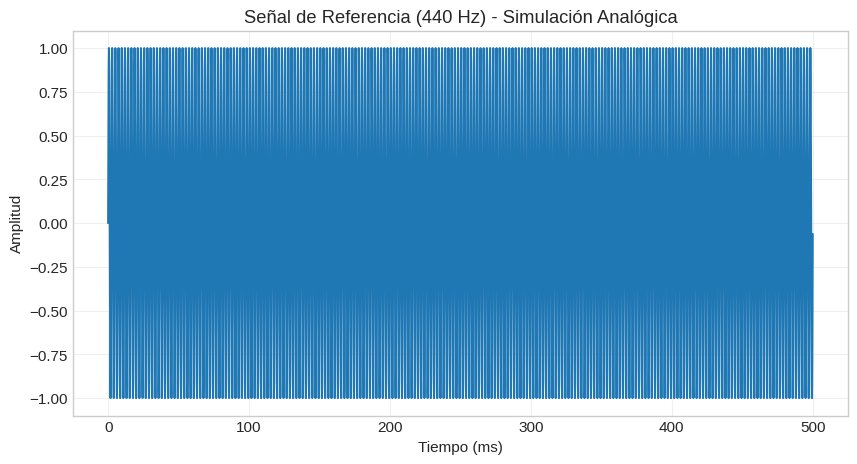

🔊 Reproduciendo tono de referencia...


In [ ]:
# Parámetros de la señal base que vamos a simular
frecuencia_objetivo = 440  # Hz (Nota La) - Frecuencia fundamental de la onda senoidal
duracion = 0.5             # segundos - Duración total de la señal generada
fs_alta = 44100            # Hz (simula continuidad) - Frecuencia de muestreo muy alta para simular una señal analógica continua

# Eje de tiempo continuo: genera puntos de tiempo desde 0 hasta la duración, con el paso determinado por fs_alta
t_ref = np.linspace(0, duracion, int(fs_alta * duracion), endpoint=False)

# Señal senoidal pura (referencia analógica simulada): calcula los valores de amplitud de la onda senoidal
senal_referencia = np.sin(2 * np.pi * frecuencia_objetivo * t_ref)

# Visualización de la señal de referencia
plt.plot(t_ref * 1000, senal_referencia, linewidth=1.5) # Grafica la señal, el tiempo se multiplica por 1000 para mostrarlo en milisegundos
plt.title('Señal de Referencia (440 Hz) - Simulación Analógica') # Título del gráfico
plt.xlabel('Tiempo (ms)') # Etiqueta del eje X
plt.ylabel('Amplitud')   # Etiqueta del eje Y
plt.grid(True, alpha=0.3) # Añade una cuadrícula al gráfico para facilitar la lectura
plt.show()               # Muestra el gráfico

# Escuchar (opcional): reproduce el tono de referencia generado
print("🔊 Reproduciendo tono de referencia...") # Mensaje indicando que el audio se va a reproducir
display(Audio(senal_referencia, rate=fs_alta)) # Usa IPython.display.Audio para reproducir la señal con la frecuencia de muestreo especificada

1.2 Efecto del Muestreo (Teorema de Nyquist)

Aquí investigamos el impacto del muestreo, el proceso de tomar 'instantáneas' de la señal analógica a intervalos regulares. Nos centraremos en el Teorema de Nyquist-Shannon, que establece la frecuencia mínima de muestreo necesaria para evitar el 'aliasing', un fenómeno donde las frecuencias altas se interpretan incorrectamente como frecuencias más bajas. Un control interactivo te permitirá experimentar con diferentes frecuencias de muestreo y observar el efecto del aliasing.

In [ ]:
def visualizar_muestreo(fs_muestreo):
    """Muestra cómo cambia la representación al variar la frecuencia de muestreo"""
    # Genera un nuevo eje de tiempo con la frecuencia de muestreo dada
    t_muestreo = np.arange(0, duracion, 1/fs_muestreo)
    # Calcula las muestras de la señal senoidal en esos puntos de tiempo
    muestras = np.sin(2 * np.pi * frecuencia_objetivo * t_muestreo)
    # Calcula la frecuencia de Nyquist (la mitad de la frecuencia de muestreo)
    f_nyquist = fs_muestreo / 2

    # Crea una nueva figura para el gráfico
    plt.figure(figsize=(10, 4))
    # Grafica la señal de referencia (simulada analógica) en gris claro como fondo
    plt.plot(t_ref * 1000, senal_referencia, 'gray', alpha=0.4, label='Referencia')
    # Grafica los puntos muestreados usando un stem plot para mostrar la naturaleza discreta
    plt.stem(t_muestreo * 1000, muestras, linefmt='b-', markerfmt='bo', basefmt='k-', label='Muestras')
    # Establece el título del gráfico, indicando la frecuencia de muestreo, Nyquist y si hay aliasing
    plt.title(f'Muestreo a {fs_muestreo} Hz | Nyquist: {f_nyquist} Hz | '
              f'{"ALIASING" if frecuencia_objetivo > f_nyquist else "Válido"}')
    plt.xlabel('Tiempo (ms)') # Etiqueta del eje X
    plt.ylabel('Amplitud')   # Etiqueta del eje Y
    plt.legend()             # Muestra la leyenda del gráfico
    plt.grid(True, alpha=0.3) # Añade una cuadrícula
    plt.show()               # Muestra el gráfico

# Control interactivo (mover el deslizador y observar el efecto en el muestreo)
print("Ajusta la frecuencia de muestreo. ¿Qué ocurre al bajar de 880 Hz?") # Instrucción para el usuario
interact(visualizar_muestreo, # Conecta la función 'visualizar_muestreo' con el widget
         fs_muestreo=widgets.IntSlider(min=400, max=2000, step=50, value=1000, description='fs (Hz):')); # Define el deslizador para la frecuencia de muestreo

Ajusta la frecuencia de muestreo. ¿Qué ocurre al bajar de 880 Hz?


interactive(children=(IntSlider(value=1000, description='fs (Hz):', max=2000, min=400, step=50), Output()), _d…

TAREA 1.2:
Encuentra el valor exacto donde aparece aliasing. ¿Por qué ocurre?
Si muestreamos a 500 Hz, ¿qué frecuencia "falsa" aparecerá?
(Pista: |f_real - fs|)

1. Valor exacto donde aparece aliasing y por qué ocurre:

Respuesta:
* Señal original: 440 Hz
* Frecuencia de Nyquist: fs/2
* Aliasing aparece cuando: fs < 880 Hz (es decir, cuando fs/2 < 440 Hz)
* Valor exacto de corte: fs = 880 Hz (justo en el límite de Nyquist)

¿Por qué ocurre?

El aliasing ocurre porque violamos el Teorema de Nyquist-Shannon, que establece que para reconstruir fielmente una señal, debemos muestrear al menos al doble de su frecuencia máxima. Cuando muestreamos por debajo de este límite:

* Las muestras no capturan suficientes puntos de la onda original
* El sistema "interpreta mal" la frecuencia real
* Frecuencias altas se "disfrazan" como frecuencias bajas

Es análogo a ver una rueda de carroza en cámara lenta que parece girar al revés

2. Frecuencia "falsa" al muestrear a 500 Hz:

Cálculo:

f_real = 440 Hz
fs = 500 Hz
f_nyquist = fs/2 = 250 Hz

Como 440 Hz > 250 Hz → HAY ALIASING

Frecuencia alias = |f_real - n·fs|

Probamos con n=1:
|440 - 500| = |−60| = 60 Hz

Verificación con n=0:
|440 - 0| = 440 Hz (pero esto es > f_nyquist, no es válido)

**FRECUENCIA FALSA: 60 Hz**

Interpretación: Una señal de 440 Hz muestreada a 500 Hz aparecerá como si fuera de 60 Hz (un tono muy grave), ¡casi 7 veces más bajo!

1.3 Efecto de la Cuantización

En esta parte, examinamos el efecto de la cuantización, que es el proceso de asignar un valor discreto (un número) a cada muestra de audio. La cantidad de 'bits' utilizados para esta asignación determina la resolución y el rango dinámico de la señal digitalizada. Un menor número de bits puede llevar a 'ruido de cuantización' y a una menor fidelidad de la señal. Exploraremos cómo los bits afectan la calidad del audio y por qué el audio profesional utiliza una alta resolución en bits.

In [ ]:
def visualizar_cuantizacion(bits):
    """Aplica cuantización y muestra el error de redondeo"""
    # Muestreamos primero la señal a una tasa segura para evitar aliasing en esta etapa
    fs_seguro = 2000
    # Creamos un eje de tiempo muestreado
    t_seguro = np.arange(0, duracion, 1/fs_seguro)
    # Generamos la señal senoidal muestreada
    senal_muestreada = np.sin(2 * np.pi * frecuencia_objetivo * t_seguro)

    # Calculamos el número total de niveles de cuantización basados en los bits
    niveles = 2**bits
    # Cuantizamos la señal: escalamos, redondeamos y volvemos a escalar
    # (niveles/2 - 1) se usa para cuantificación simétrica alrededor de cero
    senal_cuantizada = np.round(senal_muestreada * (niveles/2 - 1)) / (niveles/2 - 1)

    # Creamos la figura para la visualización
    plt.figure(figsize=(10, 4))
    # Graficamos la señal muestreada (como si fuera continua para referencia)
    plt.plot(t_seguro * 1000, senal_muestreada, 'gray', alpha=0.5, label='Muestreada (continua)')
    # Graficamos la señal cuantizada, que mostrará los 'escalones'
    plt.plot(t_seguro * 1000, senal_cuantizada, 'r-', linewidth=2, label=f'Cuantizada ({bits} bits)')
    # Añadimos el título con la información de los bits y niveles
    plt.title(f'Cuantización: {bits} bits → {niveles} niveles')
    # Etiquetas para los ejes
    plt.xlabel('Tiempo (ms)')
    plt.ylabel('Amplitud cuantizada')
    # Mostramos la leyenda
    plt.legend()
    # Añadimos una cuadrícula
    plt.grid(True, alpha=0.3)
    # Mostramos el gráfico
    plt.show()

print("Observa cómo los 'escalones' aumentan al reducir los bits:")
# Creamos un control interactivo para ajustar los bits y ver el efecto de la cuantización
interact(visualizar_cuantizacion,
         bits=widgets.IntSlider(min=2, max=8, step=1, value=4, description='Bits:'));

Observa cómo los 'escalones' aumentan al reducir los bits:


interactive(children=(IntSlider(value=4, description='Bits:', max=8, min=2), Output()), _dom_classes=('widget-…

TAREA 1.3:

¿Por qué el audio profesional usa 24 bits y no 8? Menciona 2 razones técnicas y 1 razón práctica.

2 Razones Técnicas:

1. Mayor rango dinámico y menor ruido de cuantización:

* 8 bits: 2^8 = 256 niveles → Rango dinámico ≈ 48 dB
* 24 bits: 2^24 = 16,777,216 niveles → Rango dinámico ≈ 144 dB
* Diferencia: 96 dB adicionales, lo que significa que se pueden capturar sonidos muy suaves y muy fuertes simultáneamente sin distorsión ni pérdida de detalle

2. Mayor resolución de amplitud (precisión):

* Con 8 bits, el "escalón" entre niveles es grande → error de redondeo significativo
* Con 24 bits, los escalones son microscópicos → la señal digitalizada es prácticamente indistinguible de la analógica
* Esto es crítico en producción profesional donde se aplican múltiples procesos (EQ, compresión, reverb) que amplifican el ruido de cuantización

1 Razón Práctica:

1. Headroom para post-producción y mezcla:

* En estudio se graba a 24 bits para tener "margen de maniobra" durante la edición
* Permite aplicar ganancia, ecualización y efectos sin introducir artefactos audibles
* Luego se puede reducir a 16 bits (CD) o comprimir a MP3 para distribución final
* Es mejor tener información de sobra y descartarla después, que perderla desde la grabación

MÓDULO 2: PREPARACIÓN DE DATOS CRUDOS

Objetivo: Transformar una señal "cruda" (con ruido, silencios y duración variable) en un audio limpio y estandarizado listo para análisis.

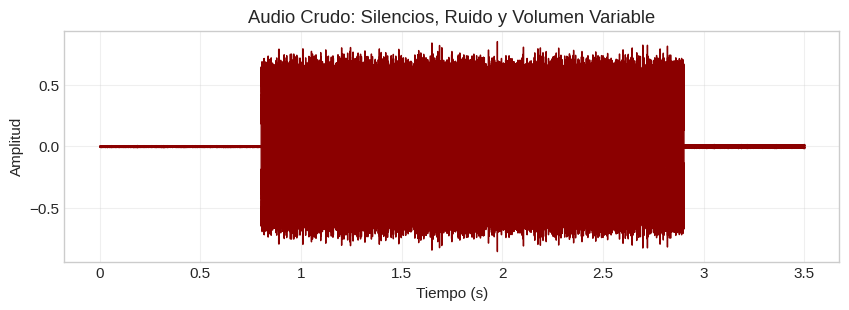

📏 Duración: 3.50s | Amplitud máx: 0.853


In [ ]:
# Generamos un audio "crudo" con problemas típicos para simular un escenario real
# Definimos la frecuencia de muestreo para el audio crudo
fs_crudo = 44100
# Creamos un vector de tiempo para el audio crudo, con una duración de 3.5 segundos
t_crudo = np.linspace(0, 3.5, int(fs_crudo * 3.5), endpoint=False)

# Señal base: una combinación de dos ondas senoidales (440 Hz y 880 Hz)
# Multiplicamos por 0.7 y 0.3 para simular diferentes amplitudes y complejidades tonales
senal_cruda = (0.7 * np.sin(2 * np.pi * 440 * t_crudo) +
               0.3 * np.sin(2 * np.pi * 880 * t_crudo))
# Añadimos ruido aleatorio (ruido blanco) para simular condiciones de grabación imperfectas
senal_cruda += 0.15 * np.random.randn(len(t_crudo))  # Ruido gaussiano
# Introducimos un 'silencio' inicial reduciendo drásticamente la amplitud de los primeros 0.8 segundos
senal_cruda[:int(0.8*fs_crudo)] *= 0.01              # Simula un silencio o una parte muy baja al inicio
# Introducimos un 'silencio' final reduciendo la amplitud de los últimos 0.6 segundos
senal_cruda[-int(0.6*fs_crudo):] *= 0.02             # Simula un desvanecimiento o un silencio al final
# Reducimos el volumen general de la señal para simular una grabación con bajo nivel de ganancia
senal_cruda *= 0.6                                   # Reduce la amplitud máxima

# ---- Diagnóstico visual inicial de la señal cruda ----
# Creamos una figura para el gráfico con un tamaño específico
plt.figure(figsize=(10, 3))
# Usamos librosa.display.waveshow para visualizar la forma de onda del audio crudo
librosa.display.waveshow(senal_cruda, sr=fs_crudo, color='darkred')
# Establecemos el título del gráfico para describir su contenido
plt.title('Audio Crudo: Silencios, Ruido y Volumen Variable')
# Etiquetamos el eje X como 'Tiempo (s)'
plt.xlabel('Tiempo (s)')
# Etiquetamos el eje Y como 'Amplitud'
plt.ylabel('Amplitud')
# Añadimos una cuadrícula semi-transparente para facilitar la lectura
plt.grid(True, alpha=0.3)
# Mostramos el gráfico
plt.show()

# Imprimimos metadatos básicos del audio crudo
# Duración en segundos y amplitud máxima absoluta para entender su estado inicial
print(f"📏 Duración: {len(senal_cruda)/fs_crudo:.2f}s | Amplitud máx: {np.max(np.abs(senal_cruda)):.3f}")

2.2 Pipeline de Limpieza y Normalización

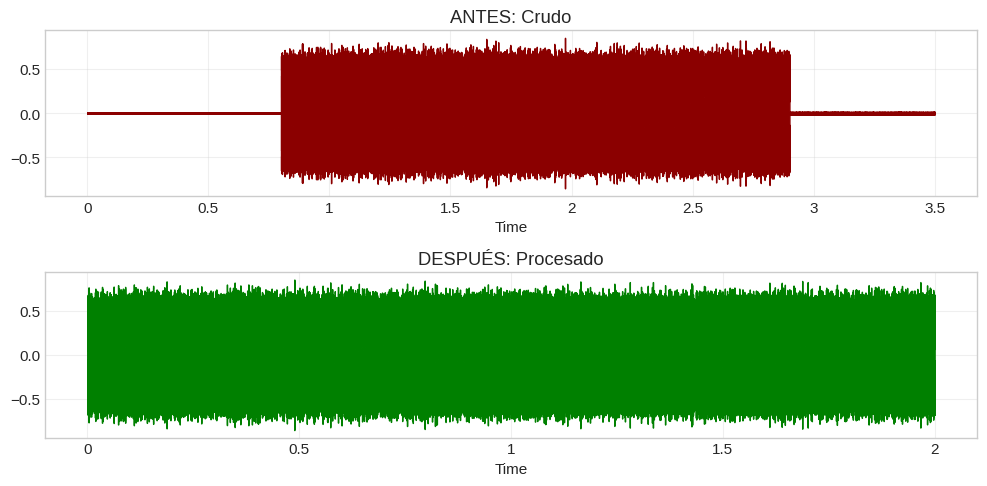

METADATOS DE TRANSFORMACIÓN:
  • dur_original: 3.5
  • amp_max_original: 0.8530057992547239
  • ajuste_dur: crop
  • dur_final: 2.0
  • amp_max_final: 0.8566621541976929
  • sr_final: 22050


In [ ]:
def pipeline_preprocesamiento(audio, sr, target_sr=22050, target_dur=2.0, top_db=30):
    """Pipeline secuencial: Trim → Normalizar → Resample → Ajustar duración"""
    # Almacenamos metadatos iniciales para comparación posterior
    metadatos = {'dur_original': len(audio)/sr, 'amp_max_original': np.max(np.abs(audio))}

    # 1️⃣ Recortar silencios (Trim)
    # librosa.effects.trim detecta y elimina segmentos de bajo volumen al inicio y al final de la señal.
    # top_db define el umbral de decibeles por debajo del cual se considera silencio.
    audio_trim, _ = librosa.effects.trim(audio, top_db=top_db)

    # 2️⃣ Normalizar amplitud (Peak Normalization)
    # Escalamos la señal para que su amplitud máxima (absoluta) sea 1.0. Esto evita saturación y maximiza el rango dinámico.
    # Se comprueba que la señal no sea completamente silenciosa para evitar división por cero.
    if np.max(np.abs(audio_trim)) > 0:
        audio_norm = audio_trim / np.max(np.abs(audio_trim))
    else:
        audio_norm = audio_trim # Si es silencio, no se normaliza (ya está en 0)

    # 3️⃣ Remuestrear a frecuencia estándar (Resample)
    # Cambiamos la frecuencia de muestreo de la señal para estandarizarla a un valor común (target_sr).
    # Esto es crucial para modelos de ML que esperan una entrada de SR fijo y para reducir datos si es necesario.
    if sr != target_sr:
        audio_proc = librosa.resample(audio_norm, orig_sr=sr, target_sr=target_sr)
        sr = target_sr # Actualizamos la frecuencia de muestreo de la señal procesada
    else:
        audio_proc = audio_norm # Si ya tiene la SR objetivo, no se remuestrea

    # 4️⃣ Ajustar duración exacta (Crop centrado o Pad)
    # Establecemos la duración de la señal a un valor fijo (target_dur) en segundos.
    # Si es más larga, se recorta el centro; si es más corta, se rellena con ceros.
    samples_obj = int(target_dur * sr)
    if len(audio_proc) > samples_obj:
        # Si la señal es más larga, se calcula el inicio para un recorte centrado
        inicio = (len(audio_proc) - samples_obj) // 2
        audio_proc = audio_proc[inicio:inicio + samples_obj]
        metadatos['ajuste_dur'] = 'crop' # Registramos que se realizó un recorte
    else:
        # Si la señal es más corta, se rellena con ceros al final para alcanzar la duración objetivo
        audio_proc = np.pad(audio_proc, (0, samples_obj - len(audio_proc)), mode='constant')
        metadatos['ajuste_dur'] = 'pad' # Registramos que se realizó un relleno

    # Actualizamos los metadatos con la información de la señal final
    metadatos.update({
        'dur_final': target_dur,
        'amp_max_final': np.max(np.abs(audio_proc)),
        'sr_final': sr
    })

    return audio_proc, sr, metadatos

# Aplicar el pipeline de preprocesamiento a la señal cruda simulada
senal_limpia, sr_limpia, meta = pipeline_preprocesamiento(senal_cruda, fs_crudo)

# ---- Visualización de la Comparación Antes/Después del Preprocesamiento ----
# Creamos una figura con dos subgráficos para comparar la señal original y la procesada
fig, axes = plt.subplots(2, 1, figsize=(10, 5))
# Graficamos la señal cruda original en el primer subgráfico
librosa.display.waveshow(senal_cruda, sr=fs_crudo, ax=axes[0], color='darkred')
axes[0].set_title('ANTES: Crudo')
# Graficamos la señal limpia y procesada en el segundo subgráfico
librosa.display.waveshow(senal_limpia, sr=sr_limpia, ax=axes[1], color='green')
axes[1].set_title('DESPUÉS: Procesado')
# Añadimos cuadrículas a ambos subgráficos para facilitar la lectura
for ax in axes: ax.grid(True, alpha=0.3)
# Ajustamos el layout para evitar solapamiento de títulos y etiquetas
plt.tight_layout()
# Mostramos los gráficos
plt.show()

# ---- Impresión de Metadatos de Transformación ----
print("METADATOS DE TRANSFORMACIÓN:")
for k, v in meta.items(): print(f"  • {k}: {v}")

TAREA 2.2:

1. ¿Por qué normalizamos antes de remuestrear y no después?
2. Si el audio original duraba 3.5s y el objetivo es 2.0s, ¿qué porcentaje de información se descartó en el crop?
Justifica si es aceptable para análisis de voz.

TAREA 2.2: Pipeline de Normalización

1. ¿Por qué normalizamos ANTES de remuestrear y no después?
Respuesta:

Normalizar antes del remuestreo es crucial por varias razones:

a) Preservación de la relación señal/ruido durante el remuestreo:
* El remuestreo (resampling) implica interpolación y filtrado
* Si la señal tiene amplitudes muy bajas, los algoritmos de interpolación pueden introducir errores numéricos o artefactos
* Una señal normalizada (rango [-1, +1]) trabaja en el rango óptimo de precisión numérica de punto flotante

b) Evitar saturación post-remuestreo:
* Algunos algoritmos de remuestreo pueden producir "overshoot" (picos que superan el valor máximo original)
* Si normalizamos después, podríamos no detectar que el remuestreo introdujo distorsión
* Normalizar antes permite controlar mejor el proceso completo

c) Consistencia con filtros anti-aliasing:
* El remuestreo aplica filtros pasa-bajos que asumen una señal en rango normalizado
* Funciona mejor numéricamente con valores en [-1, +1]

d) Eficiencia:
* Es más eficiente normalizar una vez al inicio que después de cada transformación

2. Porcentaje de información descartada en el crop:
Cálculo:

Duración original: 3.5 s
Duración objetivo: 2.0 s
Sample rate: 22050 Hz

Samples originales: 3.5 × 22050 = 77,175 samples
Samples finales: 2.0 × 22050 = 44,100 samples

Samples descartados: 77,175 - 44,100 = 33,075 samples

Porcentaje descartado: (33,075 / 77,175) × 100 = 42.86%

**Se descartó ~43% de la información temporal**


¿Es aceptable para análisis de voz?

Depende del contexto:

**SÍ es aceptable si:**
* El comando de voz completo está contenido en los 2.0s centrales (por eso usamos crop centrado)
* Los silencios iniciales/finales ya fueron eliminados por el trimming
* La duración típica de comandos de voz es 0.5-2.0s
* El modelo de ML requiere entradas de tamaño fijo para procesamiento por lotes (batch)

**NO es aceptable si:**
* La grabación contiene información importante en los bordes (ej. consonantes finales)
* Se pierden formantes o transitorios críticos para la clasificación
* El audio original era una frase larga (>3s) que requiere contexto completo

**Solución intermedia:**
* Usar ventanas deslizantes (hop windows) en lugar de crop único
* Aplicar padding inteligente si el audio es muy corto
* Implementar detección de actividad de voz (VAD) para crop basado en contenido, no en posición

MÓDULO 3: ANÁLISIS EXPLORATORIO (EDA) CON FOURIER

Objetivo: Extraer, visualizar e interpretar características espectrales y estadísticas para entender el contenido del audio procesado.

3.1 Transformada de Fourier y Espectro de Frecuencias

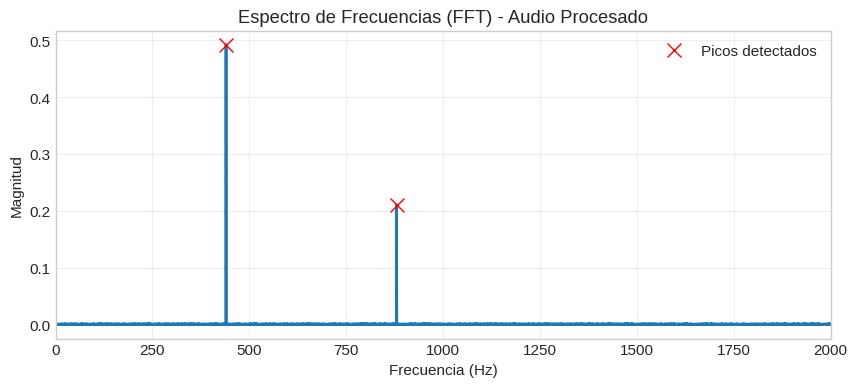

Frecuencias dominantes: ['440 Hz', '880 Hz']


In [ ]:
# ---- Configuración para la Transformada Rápida de Fourier (FFT) ----
# N: Número total de muestras en la señal limpia
N = len(senal_limpia)
# T: Período de muestreo (tiempo entre muestras), inverso de la frecuencia de muestreo
T = 1.0 / sr_limpia

# ---- Cálculo de la FFT ----
# yf: Resultado de la FFT. Contiene componentes de frecuencia complejas.
yf = np.fft.fft(senal_limpia)
# xf: Frecuencias correspondientes a cada componente de la FFT.
# np.fft.fftfreq genera las frecuencias y se toma la mitad (hasta N//2) ya que el espectro es simétrico.
xf = np.fft.fftfreq(N, T)[:N//2]
# magnitud: Amplitud de cada componente de frecuencia. Se calcula como el valor absoluto de la parte relevante de yf,
# escalado por 2.0/N para obtener la magnitud correcta (considerando la simetría y el número de muestras).
magnitud = 2.0/N * np.abs(yf[0:N//2])

# 📊 Espectro de Frecuencias (FFT) - Visualización
# Creamos una figura para el gráfico del espectro
plt.figure(figsize=(10, 4))
# Graficamos las frecuencias (xf) contra sus magnitudes (magnitud)
plt.plot(xf, magnitud, linewidth=2)
plt.title('Espectro de Frecuencias (FFT) - Audio Procesado') # Título del gráfico
plt.xlabel('Frecuencia (Hz)') # Etiqueta del eje X
plt.ylabel('Magnitud')   # Etiqueta del eje Y
plt.xlim(0, 2000)        # Limitamos el eje X para enfocarnos en las frecuencias de interés
plt.grid(True, alpha=0.3) # Añadimos una cuadrícula

# ---- Detección y Marcado de Picos Principales ----
# Importamos find_peaks de scipy.signal para identificar los picos en el espectro
from scipy.signal import find_peaks
# Encontramos los picos con una altura mínima de 0.1 y una distancia mínima de 50 puntos entre ellos
peaks, _ = find_peaks(magnitud, height=0.1, distance=50)
# Marcamos los picos detectados en el gráfico con cruces rojas
plt.plot(xf[peaks], magnitud[peaks], 'rx', markersize=10, label='Picos detectados')
plt.legend() # Mostramos la leyenda
plt.show()   # Mostramos el gráfico

# Imprimimos las frecuencias dominantes encontradas (los primeros 3 picos)
print(f"Frecuencias dominantes: {[f'{xf[p]:.0f} Hz' for p in peaks[:3]]}")

3.2 Espectrograma (STFT) - Tiempo + Frecuencia

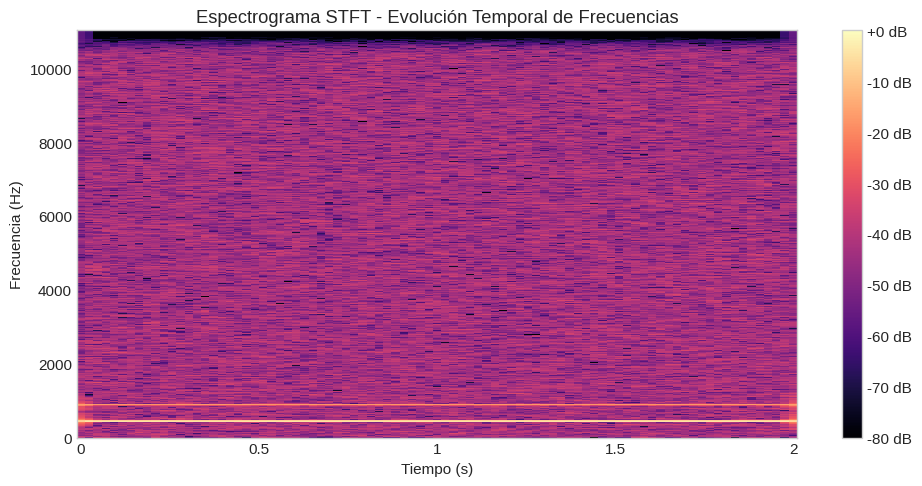

In [ ]:
# ---- Cálculo del Espectrograma (STFT) ----
# D: Matriz compleja resultante de la Short-Time Fourier Transform (STFT).
# librosa.stft divide la señal en ventanas cortas y aplica la FFT a cada una.
# n_fft=2048: Tamaño de la ventana FFT. Determina la resolución de frecuencia.
# hop_length=512: Número de muestras para avanzar entre ventanas. Determina la resolución de tiempo y el solapamiento.
D = librosa.stft(senal_limpia, n_fft=2048, hop_length=512)

# S_db: Espectrograma en escala de decibelios.
# np.abs(D) calcula la magnitud de los componentes complejos.
# librosa.amplitude_to_db convierte la amplitud a decibelios (dB), lo que es útil para visualizar un amplio rango dinámico.
# ref=np.max normaliza la escala de dB con respecto al valor máximo de la amplitud.
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

# ---- Visualización del Espectrograma ----
# Creamos una figura para el espectrograma
plt.figure(figsize=(10, 5))
# librosa.display.specshow: Función para visualizar espectrogramas.
# S_db: La matriz de decibelios a visualizar.
# sr=sr_limpia: Frecuencia de muestreo de la señal original.
# x_axis='time': Configura el eje X para mostrar el tiempo.
# y_axis='hz': Configura el eje Y para mostrar la frecuencia en Hz.
# hop_length=512: Se especifica de nuevo para una correcta visualización de tiempo.
# cmap='magma': Mapa de colores para la visualización.
img = librosa.display.specshow(S_db, sr=sr_limpia, x_axis='time', y_axis='hz',
                               hop_length=512, cmap='magma')
plt.title('Espectrograma STFT - Evolución Temporal de Frecuencias') # Título del gráfico
plt.xlabel('Tiempo (s)') # Etiqueta del eje X
plt.ylabel('Frecuencia (Hz)') # Etiqueta del eje Y
# Añadimos una barra de color para indicar la escala de decibelios
plt.colorbar(img, format='%+2.0f dB')
plt.tight_layout() # Ajusta el diseño para evitar solapamiento
plt.show() # Muestra el gráfico

3.3 Extracción de Features y Análisis Estadístico

/tmp/ipykernel_1986/4205997667.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eda, x='clase', y=feat, ax=axes[idx], palette='pastel')
/tmp/ipykernel_1986/4205997667.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eda, x='clase', y=feat, ax=axes[idx], palette='pastel')
/tmp/ipykernel_1986/4205997667.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eda, x='clase', y=feat, ax=axes[idx], palette='pastel')


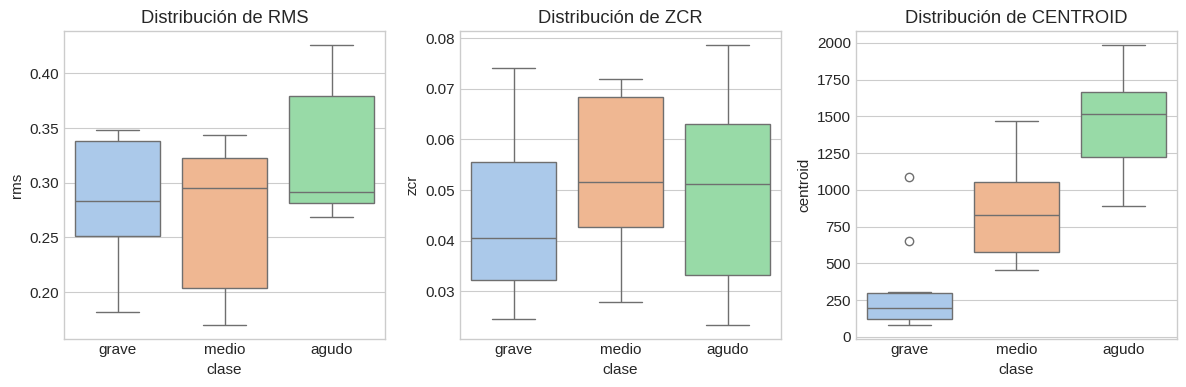

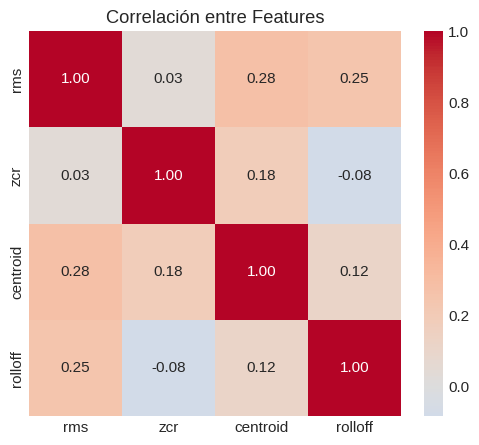

FEATURES DEL AUDIO ACTUAL:
                  0
rms          0.3823
zcr          0.1094
centroid  3895.8409
rolloff   8303.4011
flatness     0.0156


In [ ]:
# ---- Extracción de Features Espectrales y Temporales ----
# Calculamos varias características de audio utilizando la librería librosa.
# Estas características resumen propiedades importantes de la señal de audio.
features = {
    'rms': librosa.feature.rms(y=senal_limpia)[0].mean(), # Root Mean Square (RMS): Energía general de la señal.
    'zcr': librosa.feature.zero_crossing_rate(senal_limpia)[0].mean(), # Zero-Crossing Rate (ZCR): Tasa de cruces por cero, útil para distinguir voz/ruido.
    'centroid': librosa.feature.spectral_centroid(y=senal_limpia, sr=sr_limpia)[0].mean(), # Centroide Espectral: "Centro de masa" de las frecuencias, indica brillo.
    'rolloff': librosa.feature.spectral_rolloff(y=senal_limpia, sr=sr_limpia)[0].mean(), # Rolloff Espectral: Frecuencia por debajo de la cual se concentra la mayor parte de la energía.
    'flatness': librosa.feature.spectral_flatness(y=senal_limpia)[0].mean() # Flatness Espectral: Medida de qué tan "ruidoso" o "tonal" es un sonido.
}

# Creamos un DataFrame de Pandas con las características extraídas del audio actual
df_features = pd.DataFrame([features])

# ---- Visualización Comparativa con Datos Simulados (Contexto EDA) ----
# Para demostrar cómo se usan estas features en un EDA, simulamos un conjunto de datos
# con 3 clases ('grave', 'medio', 'agudo') y sus respectivas características.
# Esto ayuda a entender cómo se distribuirían las features para diferentes tipos de sonidos.
clases = ['grave', 'medio', 'agudo']
datos_simulados = []
for i in range(30):
    clase = clases[i % 3] # Asignamos clases de forma cíclica
    datos_simulados.append({
        'clase': clase,
        # Generamos valores aleatorios para cada feature, con un sesgo según la clase
        'rms': np.random.uniform(0.15, 0.35) + (0.1 if clase=='agudo' else 0),
        'zcr': np.random.uniform(0.02, 0.08),
        'centroid': np.random.uniform(300, 1500) + (500 if clase=='agudo' else -300 if clase=='grave' else 0),
        'rolloff': np.random.uniform(800, 4000),
        'flatness': np.random.uniform(0.01, 0.1)
    })

# Creamos un DataFrame con los datos simulados para el EDA
df_eda = pd.DataFrame(datos_simulados)

# ---- Boxplots por Clase para Visualizar la Distribución de Features ----
# Creamos una figura con tres subgráficos para mostrar los boxplots de RMS, ZCR y Centroid
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
# Iteramos sobre las features y creamos un boxplot para cada una, agrupado por clase
for idx, feat in enumerate(['rms', 'zcr', 'centroid']):
    sns.boxplot(data=df_eda, x='clase', y=feat, ax=axes[idx], palette='pastel')
    axes[idx].set_title(f'Distribución de {feat.upper()}')
plt.tight_layout() # Ajustamos el layout
plt.show() # Mostramos los boxplots

# ---- Matriz de Correlación entre Features ----
# Calculamos y visualizamos la matriz de correlación para entender la relación entre las features.
# Esto es importante para identificar multicolinealidad en modelos de ML.
plt.figure(figsize=(6, 5))
sns.heatmap(df_eda[['rms', 'zcr', 'centroid', 'rolloff']].corr(),
            annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlación entre Features')
plt.show() # Mostramos el mapa de calor de correlación

# ---- Impresión de Features del Audio Actual ----
print("FEATURES DEL AUDIO ACTUAL:")
# Mostramos las características calculadas para la 'senal_limpia', redondeadas para mayor legibilidad
print(df_features.round(4).T)

**TAREA 3.3:**

1. Interpreta el espectrograma: ¿Las frecuencias se mantienen estables o varían con el tiempo?
2. ¿Qué feature (centroid o rolloff) esperas que sea mayor en un sonido "agudo"? ¿Por qué?
3. Si dos features tienen correlación >0.8, ¿deberías usar ambas en un modelo de Machine Learning? Justifica.

**TAREA 3.3: EDA y Features**

1. Interpretación del espectrograma:

Respuesta:
En el espectrograma generado (señal senoidal de 440 Hz + 880 Hz):

Las **frecuencias se mantienen ESTABLES en el tiempo** porque:
* Es una señal **periódica y estacionaria** (ondas senoidales puras)
* Se observan **bandas horizontales brillantes** en ~440 Hz y ~880 Hz que se extienden a lo largo de todo el eje temporal
* No hay variación en la posición vertical (frecuencia) de estas bandas
* La intensidad (color) también es constante, indicando amplitud estable

Contraste con voz real:
* La voz humana mostraría **bandas que se mueven** (formantes variables)
* Transitorios rápidos (consonantes plosivas como /p/, /t/, /k/)
* Cambios de energía a lo largo del tiempo (entonación, énfasis)

2. ¿Qué feature (centroid o rolloff) esperas que sea mayor en un sonido "agudo"?

Respuesta:

AMBAS serán mayores en un sonido agudo, pero con matices:

Spectral Centroid:
* Representa el "centro de gravedad" del espectro
* Fórmula: Σ(frecuencia × magnitud) / Σ(magnitud)
* **Sonido agudo**: La energía se concentra en frecuencias altas → centroid alto (ej. 3000-5000 Hz)
* **Sonido grave**: La energía está en frecuencias bajas → centroid bajo (ej. 200-500 Hz)

Spectral Rolloff:
* Es la frecuencia por debajo de la cual se acumula el 85% de la energía total
* **Sonido agudo**: Necesitas llegar a frecuencias más altas para acumular el 85% → rolloff alto
* **Sonido grave**: El 85% de la energía ya está en frecuencias bajas → rolloff bajo

Ejemplo numérico:

Sonido GRAVE (200 Hz fundamental):
  - Centroid: ~400 Hz
  - Rolloff: ~800 Hz

Sonido AGUDO (2000 Hz fundamental):
  - Centroid: ~2500 Hz
  - Rolloff: ~3500 Hz

Conclusión: Ambas features son indicadores de "brillo" o contenido de altas frecuencias.

3. Features con correlación >0.8 en ML:

Respuesta:

NO deberías usar ambas features si tienen correlación >0.8, y aquí las razones:

Problemas de alta correlación (multicolinealidad):

Redundancia de información:
* Si feature A y feature B están correlacionadas 0.85, esencialmente miden lo mismo
* Estás duplicando información sin agregar valor predictivo
* Aumentas la dimensionalidad innecesariamente

Inestabilidad del modelo:
* Los coeficientes del modelo se vuelven inestables y difíciles de interpretar
* Pequeños cambios en los datos producen grandes cambios en los pesos
* El modelo puede sobreajustarse (overfitting) al ruido

Problemas numéricos:
* Matrices casi singulares en algoritmos que requieren inversión de matrices (regresión lineal, LDA)
* Convergencia más lenta en algoritmos iterativos (gradiente descendente)

Importancia de features distorsionada:
* Algoritmos basados en árboles pueden dividir la importancia entre features correlacionadas
* Difícil saber cuál feature es realmente importante

Estrategias:

* Opción A: Eliminar una de las dos features (quedarse con la más interpretable o la que tenga mayor correlación con el target)

* Opción B: Aplicar PCA para combinar features correlacionadas en componentes principales

* Opción C: Usar regularización (L1/Lasso o L2/Ridge) que maneja mejor la multicolinealidad

* Excepción: Algunos modelos como Random Forest o XGBoost son más robustos a correlación alta, pero igual es buena práctica eliminar redundancia.

**CIERRE SECUENCIAL: INTEGRACIÓN Y REFLEXIÓN**

Síntesis del Flujo Completo

Señal Analógica → [Muestreo + Cuantización] → Audio Digital Crudo
       → [Trim + Normalización + Resample] → Audio Estandarizado
       → [FFT + STFT + Features] → Insights para Modelado

**TAREA FINAL INTEGRADORA**

Responde en tu cuaderno o documento:

1. Conexión conceptual: ¿Cómo afecta un mal muestreo (aliasing) en el Módulo 1 a los resultados del EDA en el Módulo 3?
2. Decisión técnica: Si tuvieras que procesar 1000 audios de comandos de voz para un asistente virtual, ¿qué parámetros (fs, bits, top_db, n_fft) elegirías y por qué?

```
# Esto tiene formato de código
```


3. Extensión real: ¿Qué cambiarías en este pipeline si en lugar de voz trabajaras con cantos de aves o ruido industrial?

**TAREA FINAL INTEGRADORA**

1. El aliasing tiene efectos catastróficos en cascada que se propagan hasta el EDA:

a) Distorsión del espectro de frecuencias (FFT):

* Las frecuencias reales altas aparecen como frecuencias falsas bajas
* Ejemplo: Un formante de voz en 6000 Hz muestreado a 8000 Hz aparecerá en 2000 Hz
* Consecuencia: El análisis espectral es completamente erróneo

b) Features espectrales incorrectas:
* Spectral Centroid: Subestimado (la energía "se mueve" a frecuencias más bajas)
* Spectral Rolloff: Subestimado
* MFCCs: Todos los coeficientes están contaminados
* Consecuencia: El modelo de ML entrenará con características falsas

c) Pérdida de información discriminativa:
* Si trabajas con voz, los formantes altos (críticos para distinguir vocales) se pierden o distorsionan
* Si trabajas con música, los armónicos altos (que definen el timbre) se convierten en ruido
* Consecuencia: Imposibilidad de clasificar correctamente

d) Correlaciones espurias:
* El aliasing introduce patrones artificiales que el EDA puede interpretar como relaciones reales
* Consecuencia: Conclusiones erróneas sobre el dataset

Ejemplo concreto:

Escenario SIN aliasing (fs=44100 Hz):
  - Centroid clase "agudo": 3500 Hz
  - Centroid clase "grave": 500 Hz
  → Clases bien separadas ✅

Escenario CON aliasing (fs=6000 Hz):
  - Frecuencias >3000 Hz se pliegan
  - Centroid clase "agudo": 1800 Hz (falso!)
  - Centroid clase "grave": 500 Hz
  → Separación reducida, solapamiento ❌
  → Modelo de ML con accuracy baja


  Conclusión: El aliasing invalida todo el análisis posterior. Es crítico respetar Nyquist desde el inicio.

2. Decisión técnica: Parámetros para asistente de voz

Si tuvieras que procesar 1000 audios de comandos de voz para un asistente virtual, ¿qué parámetros elegirías y por qué?

Respuesta:

Parámetros propuestos:

In [ ]:
fs = 16000 Hz        # Frecuencia de muestreo
bits = 16            # Profundidad de bits
top_db = 30          # Umbral para trimming
n_fft = 512          # Tamaño de ventana para STFT
hop_length = 256     # Superposición (50%)
duracion_objetivo = 1.0  # segundos

SyntaxError: invalid syntax (1937967203.py, line 1)

Justificación técnica:

a) fs = 16000 Hz (16 kHz):

✅ Razones:
Equilibrio entre eliminar silencios y preservar partes suaves de la voz
Típico para voz: 20-40 dB
Elimina ruido de fondo muy bajo sin cortar consonantes finales suaves
❌ No usar 10 dB: Demasiado agresivo, corta partes válidas de la señal
❌ No usar 60 dB: Demasiado conservador, deja mucho ruido de fondoRazones:

* Rango de voz humana: 80 Hz - 8000 Hz (fundamental + armónicos)
* Nyquist: 16000/2 = 8000 Hz → cubre todo el rango de voz
* **Estándar industrial**: Google Speech Commands, Alexa, Siri usan 16 kHz
* Eficiencia: Mitad de datos que 44100 Hz, sin pérdida de inteligibilidad
* Suficiente para comandos cortos (no se necesita calidad musical)

❌ No usar 8000 Hz: Aunque es estándar telefónico, pierde frecuencias >4000 Hz (consonantes fricativas como /s/, /f/ son cruciales)

❌ No usar 44100 Hz: Overkill para voz, 3× más datos sin beneficio para clasificación

b) bits = 16:

✅ Razones:

* Rango dinámico: 96 dB (suficiente para voz en ambiente controlado)
* Estándar WAV/CD
* Equilibrio calidad/tamaño
* Compatible con todas las librerías

❌ No usar 8 bits: 48 dB de rango dinámico es insuficiente, introduce ruido de cuantización audible

❌ No usar 24 bits: Ocupa 50% más espacio sin beneficio perceptible para comandos de voz (luego se normaliza igual)

c) top_db = 30:

✅ Razones:

* Equilibrio entre eliminar silencios y preservar partes suaves de la voz
* Típico para voz: 20-40 dB
* Elimina ruido de fondo muy bajo sin cortar consonantes finales suaves

❌ No usar 10 dB: Demasiado agresivo, corta partes válidas de la señal

❌ No usar 60 dB: Demasiado conservador, deja mucho ruido de fondo

d) n_fft = 512:

✅ Razones:

* Resolución temporal: 512/16000 = 32 ms (buena para fonemas rápidos)
* Resolución frecuencial: 16000/512 = 31.25 Hz/bin (suficiente para distinguir formantes)
* Compromiso óptimo para voz: los fonemas duran 30-100 ms
* Potencia de 2 → FFT eficiente

❌ No usar 2048: Resolución temporal de 128 ms es demasiado lenta, pierdes transitorios

❌ No usar 128: Resolución frecuencial de 125 Hz/bin es muy gruesa, no distingues formantes cercanos

e) hop_length = 256 (50% overlap):

✅ Razones:

* Superposición del 50% es estándar en procesamiento de voz
* Suaviza transiciones entre ventanas
* Captura eventos que caen en bordes de ventana
* Balance entre resolución temporal y costo computacional

f) duracion_objetivo = 1.0 s:

✅ Razones:

* Comandos típicos ("sí", "no", "izquierda", "derecha") duran 0.3-1.0s
* Tamaño fijo necesario para redes neuronales (CNN/RNN)
* 1.0s cubre la mayoría de comandos sin desperdicio
* Si es más corto → padding; si es más largo → crop centrado

Pipeline completo propuesto:

In [ ]:
def pipeline_asistente_voz(audio, sr):
    # Esta función implementa el pipeline de preprocesamiento para audios de comandos de voz
    # con los parámetros óptimos discutidos anteriormente.

    # 1. Remuestrear (Resample) a 16 kHz si la frecuencia de muestreo original es diferente
    # Esto estandariza todos los audios a la frecuencia de muestreo ideal para voz.
    if sr != 16000:
        audio = librosa.resample(audio, orig_sr=sr, target_sr=16000)
        sr = 16000 # Actualizar la frecuencia de muestreo del audio

    # 2. Recortar silencios (Trim) usando un umbral de 30 dB
    # Esto elimina las partes silenciosas al inicio y al final de la grabación.
    audio, _ = librosa.effects.trim(audio, top_db=30)

    # 3. Normalizar la amplitud (Peak Normalization)
    # Escala el audio para que su amplitud máxima sea 1, evitando saturación y maximizando el rango dinámico.
    if np.max(np.abs(audio)) > 0: # Evitar división por cero si el audio es completamente silencio
        audio = audio / np.max(np.abs(audio))
    else:
        audio = np.zeros_like(audio) # Si es silencio total, se mantiene como silencio

    # 4. Ajustar duración a 1.0 segundos (target_samples = 16000)
    target_samples = sr * 1  # 1 segundo * 16000 Hz = 16000 muestras

    if len(audio) > target_samples:
        # Si el audio es más largo, se recorta el centro (crop centrado)
        inicio = (len(audio) - target_samples) // 2
        audio = audio[inicio:inicio + target_samples]
    else:
        # Si el audio es más corto, se rellena con ceros (padding) al final
        audio = np.pad(audio, (0, target_samples - len(audio)), mode='constant')

    # 5. Extraer Coeficientes Cepstrales de Frecuencia Mel (MFCCs)
    # Los MFCCs son features robustos y ampliamente usados para el reconocimiento de voz.
    # n_fft=512 para resolución frecuencial adecuada, hop_length=256 para superposición estándar.
    mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_fft=512,
                                  hop_length=256, n_mfcc=13)

    # La función devuelve el audio procesado y sus MFCCs
    return audio, mfccs

3. Extensión real: Cambios para aves o ruido industrial

¿Qué cambiarías en este pipeline si en lugar de voz trabajaras con cantos de aves o ruido industrial?

Respuesta:

CASO A: Cantos de Aves

Cambios necesarios:

1. Frecuencia de muestreo:

In [ ]:
fs = 44100 Hz # Aumentar de 16k a 44.1k

Razón:
* Cantos de aves pueden llegar a 10-15 kHz (incluso 20 kHz en algunas especies)
* Necesitas Nyquist ≥ 20-30 kHz
* Calidad similar a música, no solo inteligibilidad

2. Duración:

In [ ]:
duracion_objetivo = 3.0 - 5.0 s  # Aumentar de 1s a 3-5s

Razón:

* Los cantos de aves son más largos y complejos que comandos de voz
* Patrones temporales extensos son importantes para identificación de especie
* Necesitas contexto temporal más amplio

3. Parámetros STFT:

In [ ]:
n_fft = 2048       # Aumentar resolución frecuencial
hop_length = 512   # Mantener 25% overlap

Razón:

* Las aves tienen tonos puros y armónicos muy definidos
* Mejor resolución frecuencial (44100/2048 ≈ 21 Hz/bin) para distinguir especies
* Menor resolución temporal aceptable (los cantos cambian más lento que fonemas)

4. Features adicionales:

In [ ]:
# Agregar:
- Chroma features (patrones tonales)
- Spectral contrast (diferencia entre picos y valles)
- Tempo/onset detection (ritmo del canto)

5. Filtros:

In [ ]:
# Filtro pasa-banda: 1000 Hz - 15000 Hz
# Eliminar ruido de viento (<1000 Hz) y enfocar en rango de aves

CASO B: Ruido Industrial

Cambios necesarios:

1. Frecuencia de muestreo:

In [ ]:
fs = 48000 Hz  # O incluso 96000 Hz

Razón:

* Maquinaria industrial puede generar ultrasonidos (>20 kHz)
* Detección de fallas en rodamientos requiere frecuencias muy altas
* Análisis de vibraciones transmitidas como sonido

2. Enfoque en bajas frecuencias:

* Aunque fs es alto, el análisis se enfoca en 0-5000 Hz
* Donde está la energía de maquinaria (motores, compresores)


In [ ]:
# Aunque fs es alto, el análisis se enfoca en 0-5000 Hz
# Donde está la energía de maquinaria (motores, compresores)

3. Duración:


In [ ]:
duracion_objetivo = 10.0 - 30.0 s

Razón:

* Patrones de ruido industrial son cíclicos y largos
* Necesitas múltiples ciclos para detectar anomalías
* Monitoreo continuo, no eventos cortos



4. Features especializadas:


In [ ]:
# Agregar:
- RMS por ventanas largas (tendencia de energía)
- Crest factor (pico/RMS) → detecta impactos
- Kurtosis → detecta transitorios (fallas)
- Análisis de bandas de octava (estándar industrial)
- Envelope analysis (demodulación para detectar fallas)

5. Preprocesamiento:

In [ ]:
# NO hacer trim agresivo
# El "ruido de fondo" ES la señal de interés
top_db = 60  # Muy conservador o sin trim

# Filtros específicos:
# - Filtro notch para eliminar frecuencia de red eléctrica (50/60 Hz)
# - Filtros de banda para aislar componentes específicos

6. Normalización:

In [ ]:
# Normalizar por archivo individual O
# Normalizar global si es monitoreo continuo
# Depende si buscas cambios absolutos o relativos

## Tabla Comparativa Final

In [ ]:
import pandas as pd

# Cargar el archivo Excel en un DataFrame de pandas
df_comparativa = pd.read_excel('Tabla Comparativa.xlsx')

# Mostrar la tabla
display(df_comparativa)

print("¡Tabla comparativa cargada y mostrada con éxito!")

FileNotFoundError: [Errno 2] No such file or directory: 'Tabla Comparativa.xlsx'

**RESUMEN FINAL**

Has completado todas las tareas del Eje I. Los conceptos clave son:

✅ Módulo 1: Respeta Nyquist para evitar aliasing; más bits = mayor calidad

✅ Módulo 2: Pipeline secuencial: Trim → Normalizar → Resample → Ajustar duración

✅ Módulo 3: FFT revela frecuencias; espectrograma muestra evolución temporal; features deben ser no redundantes

✅ Integración: Cada módulo depende del anterior; parámetros se adaptan al dominio (voz/aves/industrial)